In [2]:
import os 
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

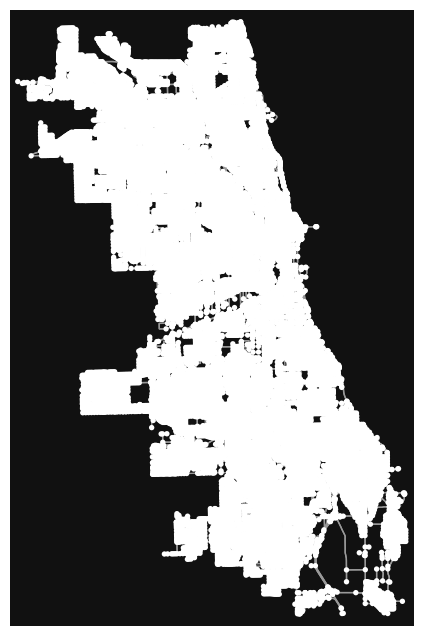

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
import osmnx as ox

## IMPORT CITY
city = ox.graph_from_place('Chicago, IL, USA', network_type='drive')

ox.plot_graph(city)

In [6]:
import networkx as nx
import numpy as np

## ADDING EDGE PROPERTIES
city = ox.speed.add_edge_speeds(city)
city = ox.speed.add_edge_travel_times(city)

## GENERATING IMPORTANT INFO
indexes = {node: i for i, node in enumerate(city.nodes)}
travel_times_dict = nx.get_edge_attributes(city, 'travel_time')

## STARTING AND ENDING NODES
str_address = '12949 S Avenue O, Chicago, IL 60633'
end_address = '5033 N Elston Ave, Chicago, IL 60630'

from utils import node_from_address, get_unique_path

starting_node = node_from_address(city, str_address)
final_node = node_from_address(city, end_address)

## FILTERING OUT UNDESIRABLE NODES, GENERATING INCIDENCE MATRIX

#banned_coords = [(40.130902, -88.243662), (40.130462, -88.238855), (40.132660, -88.243546)]

#banned_nodes = [ox.nearest_nodes(city, lon, lat) for lat, lon in banned_coords]

banned_nodes= []

edges = list(city.edges)

n_points = len(city.nodes)
n_edges = len(city.edges)

A = np.zeros((n_points, n_edges))

for i, (u, v, k) in enumerate(edges):
    if u in banned_nodes or v in banned_nodes:
        print(u, v)
        continue

    A[indexes[u]][i] = -1
    A[indexes[v]][i] = 1

Path length: 37m17s, 2236.500000000001s


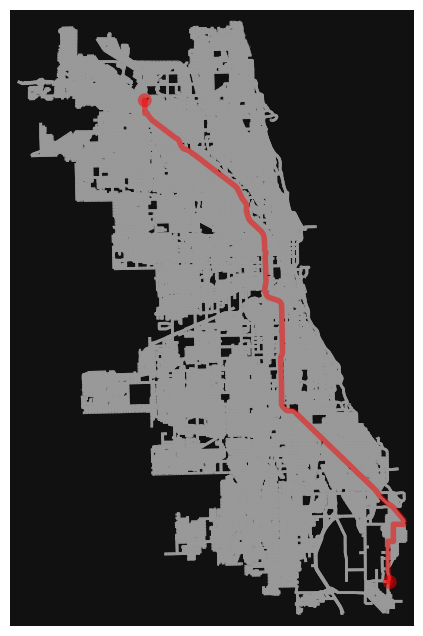

In [10]:
## LINEAR PROGRAM LOGIC
import gurobipy as gp
from gurobipy import GRB

b = np.zeros(n_points)

b[indexes[starting_node]] = -1
b[indexes[final_node]] = 1

f = np.zeros(n_edges)

m = gp.Model("lp")

m.Params.LogToConsole = 0
m.Params.Method = 0

f = m.addMVar(shape=n_edges, vtype=GRB.CONTINUOUS, lb=0, name="")

weights = [travel_time for edge, travel_time in travel_times_dict.items()]

m.addConstr(A@f==b)
obj = np.array(weights)@f
m.setObjective(obj, GRB.MINIMIZE)
m.optimize()

flows = m.getAttr("X", m.getVars())

objval = m.ObjVal

print(f'Path length: {int(objval//60)}m{round(objval%60)}s, {objval}s')

flowed_edges_idx = []
flowed_edges = []

for i in range(len(flows)):
        if flows[i]:
            flowed_edges_idx += [i]

flowed_pts = []

for i, (u, v, k) in enumerate(city.edges):
    if i in flowed_edges_idx:
        flowed_edges += [(u, v)]

        for pt in (u, v):
            if pt not in flowed_pts:
                flowed_pts += [pt]

from utils import get_route_from_edges

route_edges, route_pts  = get_unique_path(flowed_edges, starting_node=starting_node, final_node=final_node)

fig, ax = ox.plot_graph_route(city, route_pts, node_color='w', node_edgecolor='k', node_size=0, 
                           node_zorder=3, edge_linewidth=2)

Path length: 37m17s, 2236.500000000001s


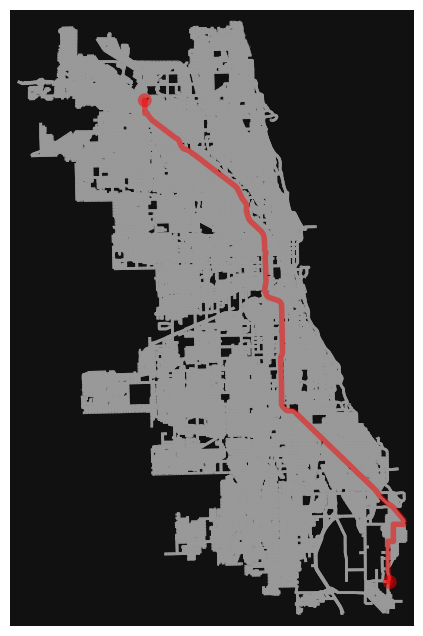

In [ ]:
## LINEAR PROGRAM LOGIC
import gurobipy as gp
from gurobipy import GRB

b = np.zeros(n_points)

b[indexes[starting_node]] = -1
b[indexes[final_node]] = 1

f = np.zeros(n_edges)

m = gp.Model("lp")

m.Params.LogToConsole = 0
m.Params.Method = 0

f = m.addMVar(shape=n_edges, vtype=GRB.CONTINUOUS, lb=0, name="")

weights = [travel_time for edge, travel_time in travel_times_dict.items()]

m.addConstr(A@f==b)
obj = np.array(weights)@f
m.setObjective(obj, GRB.MINIMIZE)
m.optimize()

flows = m.getAttr("X", m.getVars())

objval = m.ObjVal

print(f'Path length: {int(objval//60)}m{round(objval%60)}s, {objval}s')

flowed_edges_idx = []
flowed_edges = []

for i in range(len(flows)):
        if flows[i]:
            flowed_edges_idx += [i]

flowed_pts = []

for i, (u, v, k) in enumerate(city.edges):
    if i in flowed_edges_idx:
        flowed_edges += [(u, v)]

        for pt in (u, v):
            if pt not in flowed_pts:
                flowed_pts += [pt]

from utils import get_route_from_edges

route_edges, route_pts  = get_unique_path(flowed_edges, starting_node=starting_node, final_node=final_node)

fig, ax = ox.plot_graph_route(city, route_pts, node_color='w', node_edgecolor='k', node_size=0, 
                           node_zorder=3, edge_linewidth=2)

In [6]:
route_edges

[(377670237, 377670236),
 (377670236, 8251665736),
 (8251665736, 3627549048),
 (3627549048, 261200547),
 (261200547, 7256974027),
 (7256974027, 7256974028),
 (7256974028, 261145383),
 (261145383, 614352648),
 (614352648, 261200544),
 (261200544, 261200543),
 (261200543, 261177715),
 (261177715, 261177716),
 (261177716, 261177717),
 (261177717, 261177718),
 (261177718, 261177719),
 (261177719, 261238324),
 (261238324, 261323290),
 (261323290, 261117176),
 (261117176, 261186133),
 (261186133, 261252331),
 (261252331, 261211137),
 (261211137, 261218300),
 (261218300, 261218188),
 (261218188, 261218126),
 (261218126, 261218110),
 (261218110, 261275674),
 (261275674, 261218028),
 (261218028, 261218019),
 (261218019, 261218013),
 (261218013, 711516164),
 (711516164, 711516705),
 (711516705, 711516150),
 (711516150, 351100613),
 (351100613, 351099116),
 (351099116, 351097900),
 (351097900, 351096600),
 (351096600, 351094305),
 (351094305, 351093705),
 (351093705, 349895789),
 (349895789, 3498

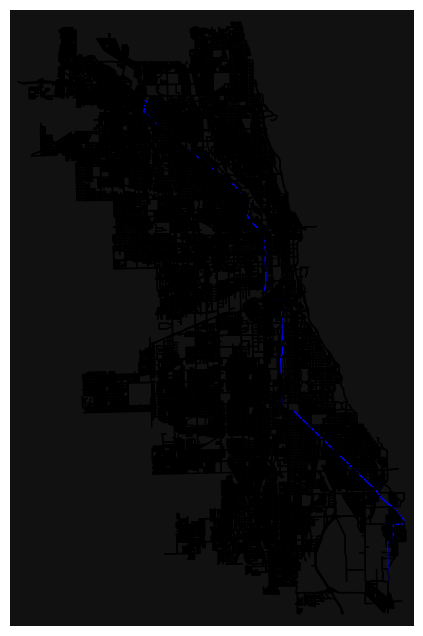

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
ec = ['b' if (u, v) in route_edges else 'black' for u, v, k in city.edges]

ox.plot_graph(city, edge_color=ec, node_size=0, edge_linewidth=1)